# **Logistic Regression Modeling**

**Purpose**
- Train and evaluate the Logistic Regression model for dengue risk classification.

**Dataset**
- Cleaned CALABARZON dengue dataset with climate, socioeconomic, and environmental variables.

**Process**
- Load the prepared dataset.
- Define feature groups and target variable.
- Train the XGBoost classification model.
- Evaluate model performance across feature sets.

**Output**
- Model performance results for the Logistic Regression model.

In [2]:
# =============================
# Import Libraries
# =============================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [3]:
# =============================
# Load Dataset
# =============================
DATA_PATH = "/Users/alexandrasantos/Downloads/Thesis_Dataset_Processed (Final).xlsx"
df = pd.read_excel(DATA_PATH)

Full Model - Logistic Regression (Climate)
Classes: ['High', 'Low', 'Medium']
X shape: (8304, 5)
Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best CV accuracy: 0.729
Best params: {'lr__solver': 'saga', 'lr__penalty': 'l2', 'lr__C': 0.05963623316594643}

Hold-out accuracy: 0.7285

Classification report:
              precision    recall  f1-score   support

        High     0.0000    0.0000    0.0000        98
         Low     0.7523    0.9704    0.8475      1183
      Medium     0.4627    0.1632    0.2412       380

    accuracy                         0.7285      1661
   macro avg     0.4050    0.3779    0.3629      1661
weighted avg     0.6417    0.7285    0.6588      1661



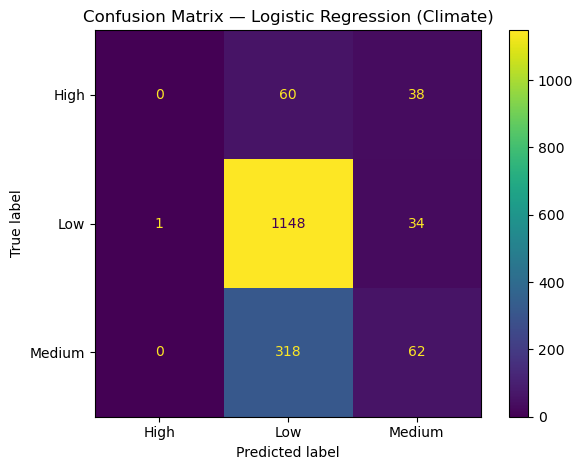

In [4]:
# ============================================================
# FULL MODEL: Climate 
# ============================================================

# -----------------------------
# Columns
# -----------------------------
TARGET_COL = "Dengue Risk Level"

CLIMATE_COLS = ["Rain", "Temperature", "Relative Humidity"]
TIME_COLS = ["Month", "Year"]

LEAKAGE_COLS = ["Dengue Cases", "Death Cases", "Dengue Incidence"]
# -----------------------------
# Validate
# -----------------------------
required = [TARGET_COL] + CLIMATE_COLS + TIME_COLS
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Drop leakage columns
df = df.drop(columns=[c for c in LEAKAGE_COLS if c in df.columns], errors="ignore")

# Remove rows with no label or time
df = df.dropna(subset=[TARGET_COL, "Month", "Year"]).copy()

# Convert Month/Year properly
df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
df["Year"]  = pd.to_numeric(df["Year"], errors="coerce")
df = df.dropna(subset=["Month", "Year"])

df["Month"] = df["Month"].astype(int)
df["Year"]  = df["Year"].astype(int)

# -----------------------------
# Build X and y
# -----------------------------
X = df[CLIMATE_COLS + TIME_COLS].copy()
y = df[TARGET_COL].astype(str)

# Numeric columns (climate + time)
numeric_cols = [
    "Rain", "Temperature", "Relative Humidity",
    "Month", "Year"
]

for c in numeric_cols:
    X[c] = pd.to_numeric(X[c], errors="coerce")

X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = list(le.classes_)
num_classes = len(class_names)

print("Full Model - Logistic Regression (Climate)")
print("Classes:", class_names)
print("X shape:", X.shape)

# -----------------------------
# Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.20,
    random_state=42,
    stratify=y_enc
)

# -----------------------------
# Logistic Regression (scaled) + Tuning
# -----------------------------
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=20000, random_state=42))
])

param_dist = {
    "lr__C": np.logspace(-4, 4, 50),
    "lr__solver": ["lbfgs", "saga"],
    "lr__penalty": ["l2"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=60,
    scoring="accuracy",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_
print("\nBest CV accuracy:", round(search.best_score_, 4))
print("Best params:", search.best_params_)

# -----------------------------
# Evaluation
# -----------------------------
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("\nHold-out accuracy:", round(acc, 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(values_format="d")
plt.title("Confusion Matrix — Logistic Regression (Climate)")
plt.tight_layout()
plt.show()

Full Model — Logistic Regression (Socioeconomic)
Classes: ['High', 'Low', 'Medium']
X shape: (8304, 14)
Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best CV accuracy: 0.7254
Best params: {'lr__solver': 'saga', 'lr__penalty': 'l2', 'lr__C': 494.1713361323828}

Hold-out accuracy: 0.7249

Classification report:
              precision    recall  f1-score   support

        High     0.6667    0.0408    0.0769        98
         Low     0.7387    0.9848    0.8442      1183
      Medium     0.4487    0.0921    0.1528       380

    accuracy                         0.7249      1661
   macro avg     0.6180    0.3726    0.3580      1661
weighted avg     0.6681    0.7249    0.6408      1661



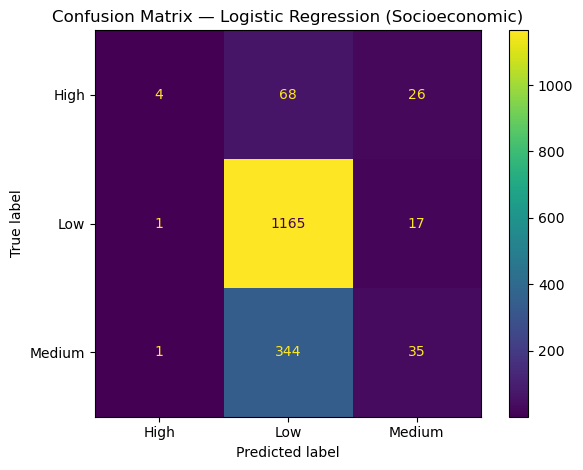

In [5]:
# ============================================================
# FULL MODEL: Socioeconomic
# ============================================================

# -----------------------------
# Columns
# -----------------------------
TARGET_COL = "Dengue Risk Level"

SOCIO_COLS = [
    "Municipal Class",
    "Total Population",
    "Settlement Type",
    "Public Healthcare Facilities",
    "Private Healthcare Facilities",
]

TIME_COLS = ["Month", "Year"]

LEAKAGE_COLS = ["Dengue Cases", "Death Cases", "Dengue Incidence"]

# -----------------------------
# Validate
# -----------------------------
required = [TARGET_COL] + SOCIO_COLS + TIME_COLS
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Drop leakage columns
df = df.drop(columns=[c for c in LEAKAGE_COLS if c in df.columns], errors="ignore")

# Remove rows with no label or time
df = df.dropna(subset=[TARGET_COL, "Month", "Year"]).copy()

# Convert Month/Year properly
df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
df["Year"]  = pd.to_numeric(df["Year"], errors="coerce")
df = df.dropna(subset=["Month", "Year"])

df["Month"] = df["Month"].astype(int)
df["Year"]  = df["Year"].astype(int)

# -----------------------------
# Build X and y
# -----------------------------
X = df[SOCIO_COLS + TIME_COLS].copy()
y = df[TARGET_COL].astype(str)

# Numeric columns
numeric_cols = [
    "Total Population",
    "Public Healthcare Facilities",
    "Private Healthcare Facilities",
    "Month",
    "Year"
]

for c in numeric_cols:
    X[c] = pd.to_numeric(X[c], errors="coerce")

X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

# Categorical columns
cat_cols = ["Municipal Class", "Settlement Type"]
for c in cat_cols:
    X[c] = X[c].astype(str).fillna("Unknown")

# One-hot encoding
X = pd.get_dummies(X, columns=cat_cols, drop_first=False)

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = list(le.classes_)

print("Full Model — Logistic Regression (Socioeconomic)")
print("Classes:", class_names)
print("X shape:", X.shape)

# -----------------------------
# Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.20,
    random_state=42,
    stratify=y_enc
)

# -----------------------------
# Logistic Regression (scaled) + Tuning
# -----------------------------
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=20000, random_state=42))
])

param_dist = {
    "lr__C": np.logspace(-4, 4, 50),
    "lr__solver": ["lbfgs", "saga"],
    "lr__penalty": ["l2"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=60,
    scoring="accuracy",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_
print("\nBest CV accuracy:", round(search.best_score_, 4))
print("Best params:", search.best_params_)

# -----------------------------
# Evaluation
# -----------------------------
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("\nHold-out accuracy:", round(acc, 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(values_format="d")
plt.title("Confusion Matrix — Logistic Regression (Socioeconomic)")
plt.tight_layout()
plt.show()

Full Model — Logistic Regression (Environmental)
Classes: ['High', 'Low', 'Medium']
X shape: (8304, 11)
Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best CV accuracy: 0.7245
Best params: {'lr__solver': 'saga', 'lr__penalty': 'l2', 'lr__C': 1.7575106248547894}

Hold-out accuracy: 0.7279

Classification report:
              precision    recall  f1-score   support

        High     0.0000    0.0000    0.0000        98
         Low     0.7375    0.9882    0.8447      1183
      Medium     0.5263    0.1053    0.1754       380

    accuracy                         0.7279      1661
   macro avg     0.4213    0.3645    0.3400      1661
weighted avg     0.6457    0.7279    0.6417      1661



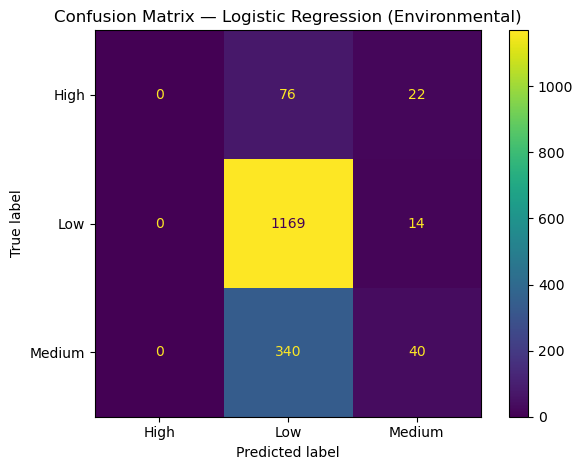

In [11]:
# ============================================================
# FULL MODEL: Environmental
# ============================================================

# -----------------------------
# Columns
# -----------------------------
TARGET_COL = "Dengue Risk Level"

ENV_COLS = [
    "Flood Hazard Level",
    "Forest Cover (%)",
    "Agricultural Land (%)",
    "Water Bodies (%)",
    "Open Vegetation (%)",
    "Built-up / Barren (%)",
]

TIME_COLS = ["Month", "Year"]

LEAKAGE_COLS = ["Dengue Cases", "Death Cases", "Dengue Incidence"]

# -----------------------------
# Validate
# -----------------------------
required = [TARGET_COL] + ENV_COLS + TIME_COLS
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Drop leakage columns
df = df.drop(columns=[c for c in LEAKAGE_COLS if c in df.columns], errors="ignore")

# Remove rows with no label or time
df = df.dropna(subset=[TARGET_COL, "Month", "Year"]).copy()

# Convert Month/Year properly
df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
df["Year"]  = pd.to_numeric(df["Year"], errors="coerce")
df = df.dropna(subset=["Month", "Year"])

df["Month"] = df["Month"].astype(int)
df["Year"]  = df["Year"].astype(int)

# -----------------------------
# Build X and y
# -----------------------------
X = df[ENV_COLS + TIME_COLS].copy()
y = df[TARGET_COL].astype(str)

# Numeric columns
numeric_cols = [
    "Forest Cover (%)",
    "Agricultural Land (%)",
    "Water Bodies (%)",
    "Open Vegetation (%)",
    "Built-up / Barren (%)",
    "Month",
    "Year"
]

for c in numeric_cols:
    X[c] = pd.to_numeric(X[c], errors="coerce")

X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

# Categorical columns
cat_cols = ["Flood Hazard Level"]
for c in cat_cols:
    X[c] = X[c].astype(str).fillna("Unknown")

# One-hot encoding
X = pd.get_dummies(X, columns=cat_cols, drop_first=False)

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = list(le.classes_)

print("Full Model — Logistic Regression (Environmental)")
print("Classes:", class_names)
print("X shape:", X.shape)

# -----------------------------
# Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.20,
    random_state=42,
    stratify=y_enc
)

# -----------------------------
# Logistic Regression (scaled) + Tuning
# -----------------------------
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=20000, random_state=42))
])

param_dist = {
    "lr__C": np.logspace(-4, 4, 50),
    "lr__solver": ["lbfgs", "saga"],
    "lr__penalty": ["l2"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=60,
    scoring="accuracy",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_
print("\nBest CV accuracy:", round(search.best_score_, 4))
print("Best params:", search.best_params_)

# -----------------------------
# Evaluation
# -----------------------------
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("\nHold-out accuracy:", round(acc, 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(values_format="d")
plt.title("Confusion Matrix — Logistic Regression (Environmental)")
plt.tight_layout()
plt.show()

Full Model — Logistic Regression (Climate + Socioeconomic)
Classes: ['High', 'Low', 'Medium']
X shape: (8304, 17)
Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best CV accuracy: 0.7348
Best params: {'lr__solver': 'saga', 'lr__penalty': 'l2', 'lr__C': 0.040949150623804234}

Hold-out accuracy: 0.7333

Classification report:
              precision    recall  f1-score   support

        High     0.4000    0.0204    0.0388        98
         Low     0.7569    0.9738    0.8518      1183
      Medium     0.4776    0.1684    0.2490       380

    accuracy                         0.7333      1661
   macro avg     0.5448    0.3875    0.3799      1661
weighted avg     0.6719    0.7333    0.6659      1661



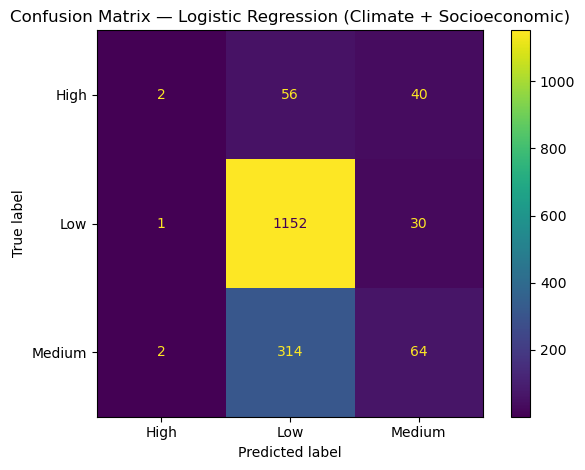

In [13]:
# ============================================================
# FULL MODEL: Climate + Socioeconomic
# ============================================================

# -----------------------------
# Columns
# -----------------------------
TARGET_COL = "Dengue Risk Level"

CLIMATE_COLS = ["Rain", "Temperature", "Relative Humidity"]

SOCIO_COLS = [
    "Municipal Class",
    "Total Population",
    "Settlement Type",
    "Public Healthcare Facilities",
    "Private Healthcare Facilities",
]

TIME_COLS = ["Month", "Year"]

LEAKAGE_COLS = ["Dengue Cases", "Death Cases", "Dengue Incidence"]

# -----------------------------
# Validate
# -----------------------------
required = [TARGET_COL] + CLIMATE_COLS + SOCIO_COLS + TIME_COLS
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Drop leakage columns
df = df.drop(columns=[c for c in LEAKAGE_COLS if c in df.columns], errors="ignore")

# Remove rows with no label or time
df = df.dropna(subset=[TARGET_COL, "Month", "Year"]).copy()

# Convert Month/Year properly
df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
df["Year"]  = pd.to_numeric(df["Year"], errors="coerce")
df = df.dropna(subset=["Month", "Year"])

df["Month"] = df["Month"].astype(int)
df["Year"]  = df["Year"].astype(int)

# -----------------------------
# Build X and y
# -----------------------------
X = df[CLIMATE_COLS + SOCIO_COLS + TIME_COLS].copy()
y = df[TARGET_COL].astype(str)

# Numeric columns
numeric_cols = [
    # Climate
    "Rain", "Temperature", "Relative Humidity",
    # Socioeconomic numeric
    "Total Population", "Public Healthcare Facilities", "Private Healthcare Facilities",
    # Time
    "Month", "Year"
]

for c in numeric_cols:
    X[c] = pd.to_numeric(X[c], errors="coerce")

X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

# Categorical columns
cat_cols = ["Municipal Class", "Settlement Type"]
for c in cat_cols:
    X[c] = X[c].astype(str).fillna("Unknown")

# One-hot encoding
X = pd.get_dummies(X, columns=cat_cols, drop_first=False)

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = list(le.classes_)

print("Full Model — Logistic Regression (Climate + Socioeconomic)")
print("Classes:", class_names)
print("X shape:", X.shape)

# -----------------------------
# Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.20,
    random_state=42,
    stratify=y_enc
)

# -----------------------------
# Logistic Regression (scaled) + Tuning
# -----------------------------
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=20000, random_state=42))
])

param_dist = {
    "lr__C": np.logspace(-4, 4, 50),
    "lr__solver": ["lbfgs", "saga"],
    "lr__penalty": ["l2"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=60,
    scoring="accuracy",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_
print("\nBest CV accuracy:", round(search.best_score_, 4))
print("Best params:", search.best_params_)

# -----------------------------
# Evaluation
# -----------------------------
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("\nHold-out accuracy:", round(acc, 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(values_format="d")
plt.title("Confusion Matrix — Logistic Regression (Climate + Socioeconomic)")
plt.tight_layout()
plt.show()

Full Model — Logistic Regression (Climate + Environmental)
Classes: ['High', 'Low', 'Medium']
X shape: (8304, 14)
Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best CV accuracy: 0.7271
Best params: {'lr__solver': 'saga', 'lr__penalty': 'l2', 'lr__C': 0.05963623316594643}

Hold-out accuracy: 0.7345

Classification report:
              precision    recall  f1-score   support

        High     0.0000    0.0000    0.0000        98
         Low     0.7549    0.9713    0.8495      1183
      Medium     0.5145    0.1868    0.2741       380

    accuracy                         0.7345      1661
   macro avg     0.4231    0.3860    0.3746      1661
weighted avg     0.6554    0.7345    0.6678      1661



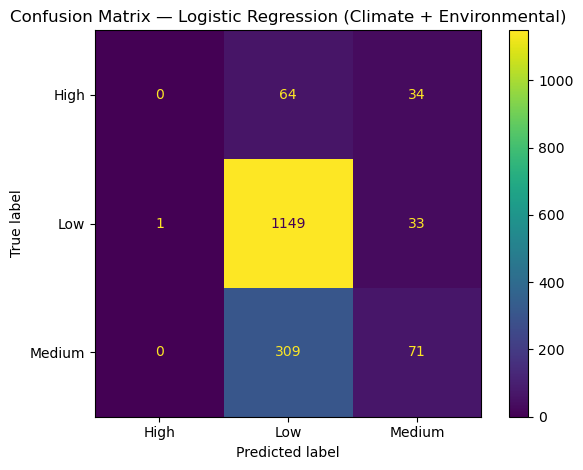

In [16]:
# ============================================================
# FULL MODEL: Climate + Environmental
# ============================================================

# -----------------------------
# Columns
# -----------------------------
TARGET_COL = "Dengue Risk Level"

CLIMATE_COLS = ["Rain", "Temperature", "Relative Humidity"]

ENV_COLS = [
    "Flood Hazard Level",
    "Forest Cover (%)",
    "Agricultural Land (%)",
    "Water Bodies (%)",
    "Open Vegetation (%)",
    "Built-up / Barren (%)",
]

TIME_COLS = ["Month", "Year"]

LEAKAGE_COLS = ["Dengue Cases", "Death Cases", "Dengue Incidence"]

# -----------------------------
# Validate
# -----------------------------
required = [TARGET_COL] + CLIMATE_COLS + ENV_COLS + TIME_COLS
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Drop leakage columns
df = df.drop(columns=[c for c in LEAKAGE_COLS if c in df.columns], errors="ignore")

# Remove rows with no label or time
df = df.dropna(subset=[TARGET_COL, "Month", "Year"]).copy()

# Convert Month/Year properly
df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
df["Year"]  = pd.to_numeric(df["Year"], errors="coerce")
df = df.dropna(subset=["Month", "Year"])

df["Month"] = df["Month"].astype(int)
df["Year"]  = df["Year"].astype(int)

# -----------------------------
# Build X and y
# -----------------------------
X = df[CLIMATE_COLS + ENV_COLS + TIME_COLS].copy()
y = df[TARGET_COL].astype(str)

# Numeric columns
numeric_cols = [
    # Climate
    "Rain", "Temperature", "Relative Humidity",
    # Environmental numeric
    "Forest Cover (%)", "Agricultural Land (%)", "Water Bodies (%)", "Open Vegetation (%)", "Built-up / Barren (%)",
    # Time
    "Month", "Year"
]

for c in numeric_cols:
    X[c] = pd.to_numeric(X[c], errors="coerce")

X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

# Categorical columns
cat_cols = ["Flood Hazard Level"]
for c in cat_cols:
    X[c] = X[c].astype(str).fillna("Unknown")

# One-hot encoding
X = pd.get_dummies(X, columns=cat_cols, drop_first=False)

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = list(le.classes_)

print("Full Model — Logistic Regression (Climate + Environmental)")
print("Classes:", class_names)
print("X shape:", X.shape)

# -----------------------------
# Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.20,
    random_state=42,
    stratify=y_enc
)

# -----------------------------
# Logistic Regression (scaled) + Tuning
# -----------------------------
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=20000, random_state=42))
])

param_dist = {
    "lr__C": np.logspace(-4, 4, 50),
    "lr__solver": ["lbfgs", "saga"],
    "lr__penalty": ["l2"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=60,
    scoring="accuracy",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_
print("\nBest CV accuracy:", round(search.best_score_, 4))
print("Best params:", search.best_params_)

# -----------------------------
# Evaluation
# -----------------------------
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("\nHold-out accuracy:", round(acc, 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(values_format="d")
plt.title("Confusion Matrix — Logistic Regression (Climate + Environmental)")
plt.tight_layout()
plt.show()

Full Model — Logistic Regression (Socioeconomic + Environmental)
Classes: ['High', 'Low', 'Medium']
X shape: (8304, 23)
Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best CV accuracy: 0.7247
Best params: {'lr__solver': 'saga', 'lr__penalty': 'l2', 'lr__C': 494.1713361323828}

Hold-out accuracy: 0.7225

Classification report:
              precision    recall  f1-score   support

        High     0.6667    0.0408    0.0769        98
         Low     0.7361    0.9831    0.8418      1183
      Medium     0.4400    0.0868    0.1451       380

    accuracy                         0.7225      1661
   macro avg     0.6142    0.3703    0.3546      1661
weighted avg     0.6642    0.7225    0.6373      1661



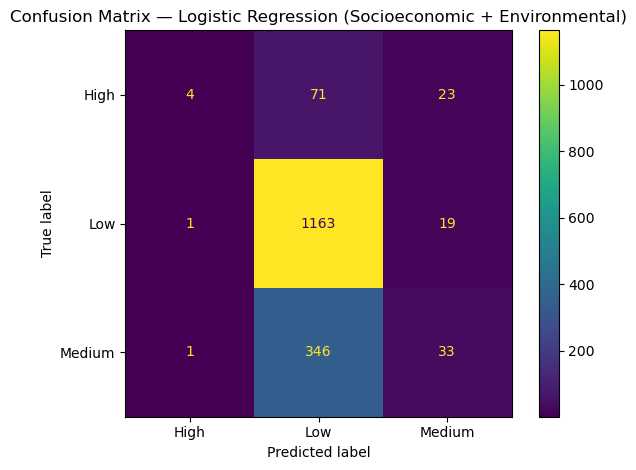

In [18]:
# ============================================================
# FULL MODEL: Socioeconomic + Environmental
# ============================================================

# -----------------------------
# Columns
# -----------------------------
TARGET_COL = "Dengue Risk Level"

SOCIO_COLS = [
    "Municipal Class",
    "Total Population",
    "Settlement Type",
    "Public Healthcare Facilities",
    "Private Healthcare Facilities",
]

ENV_COLS = [
    "Flood Hazard Level",
    "Forest Cover (%)",
    "Agricultural Land (%)",
    "Water Bodies (%)",
    "Open Vegetation (%)",
    "Built-up / Barren (%)",
]

TIME_COLS = ["Month", "Year"]

LEAKAGE_COLS = ["Dengue Cases", "Death Cases", "Dengue Incidence"]

# -----------------------------
# Validate
# -----------------------------
required = [TARGET_COL] + SOCIO_COLS + ENV_COLS + TIME_COLS
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Drop leakage columns
df = df.drop(columns=[c for c in LEAKAGE_COLS if c in df.columns], errors="ignore")

# Remove rows with no label or time
df = df.dropna(subset=[TARGET_COL, "Month", "Year"]).copy()

# Convert Month/Year properly
df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
df["Year"]  = pd.to_numeric(df["Year"], errors="coerce")
df = df.dropna(subset=["Month", "Year"])

df["Month"] = df["Month"].astype(int)
df["Year"]  = df["Year"].astype(int)

# -----------------------------
# Build X and y
# -----------------------------
X = df[SOCIO_COLS + ENV_COLS + TIME_COLS].copy()
y = df[TARGET_COL].astype(str)

# Numeric columns
numeric_cols = [
    # Socio numeric
    "Total Population", "Public Healthcare Facilities", "Private Healthcare Facilities",
    # Environmental numeric
    "Forest Cover (%)", "Agricultural Land (%)", "Water Bodies (%)", "Open Vegetation (%)", "Built-up / Barren (%)",
    # Time
    "Month", "Year"
]

for c in numeric_cols:
    X[c] = pd.to_numeric(X[c], errors="coerce")
X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

# Categorical columns
cat_cols = ["Municipal Class", "Settlement Type", "Flood Hazard Level"]
for c in cat_cols:
    X[c] = X[c].astype(str).fillna("Unknown")

# One-hot encoding
X = pd.get_dummies(X, columns=cat_cols, drop_first=False)

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = list(le.classes_)

print("Full Model — Logistic Regression (Socioeconomic + Environmental)")
print("Classes:", class_names)
print("X shape:", X.shape)

# -----------------------------
# Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.20,
    random_state=42,
    stratify=y_enc
)

# -----------------------------
# Logistic Regression (scaled) + Tuning
# -----------------------------
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=20000, random_state=42))
])

param_dist = {
    "lr__C": np.logspace(-4, 4, 50),
    "lr__solver": ["lbfgs", "saga"],
    "lr__penalty": ["l2"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=60,
    scoring="accuracy",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_
print("\nBest CV accuracy:", round(search.best_score_, 4))
print("Best params:", search.best_params_)

# -----------------------------
# Evaluation
# -----------------------------
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("\nHold-out accuracy:", round(acc, 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(values_format="d")
plt.title("Confusion Matrix — Logistic Regression (Socioeconomic + Environmental)")
plt.tight_layout()
plt.show()

Full Model — Logistic Regression (Climate + Socioeconomic + Environmental)
Classes: ['High', 'Low', 'Medium']
X shape: (8304, 26)
Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best CV accuracy: 0.7337
Best params: {'lr__solver': 'saga', 'lr__penalty': 'l2', 'lr__C': 0.12648552168552957}

Hold-out accuracy: 0.7393

Classification report:
              precision    recall  f1-score   support

        High     0.5714    0.0408    0.0762        98
         Low     0.7604    0.9713    0.8530      1183
      Medium     0.5245    0.1974    0.2868       380

    accuracy                         0.7393      1661
   macro avg     0.6188    0.4031    0.4053      1661
weighted avg     0.6953    0.7393    0.6776      1661



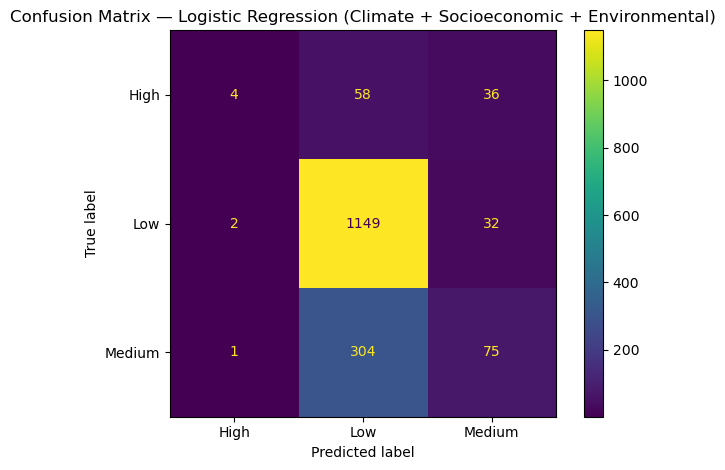

In [20]:
# ============================================================
# FULL MODEL: Climate + Socioeconomic + Environmental
# ============================================================

# -----------------------------
# Columns
# -----------------------------
TARGET_COL = "Dengue Risk Level"

CLIMATE_COLS = ["Rain", "Temperature", "Relative Humidity"]

SOCIO_COLS = [
    "Municipal Class",
    "Total Population",
    "Settlement Type",
    "Public Healthcare Facilities",
    "Private Healthcare Facilities",
]

ENV_COLS = [
    "Flood Hazard Level",
    "Forest Cover (%)",
    "Agricultural Land (%)",
    "Water Bodies (%)",
    "Open Vegetation (%)",
    "Built-up / Barren (%)",
]

TIME_COLS = ["Month", "Year"]

LEAKAGE_COLS = ["Dengue Cases", "Death Cases", "Dengue Incidence"]

ALL_FEATURES = CLIMATE_COLS + SOCIO_COLS + ENV_COLS + TIME_COLS

# -----------------------------
# Validate
# -----------------------------
required = [TARGET_COL] + ALL_FEATURES
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Drop leakage columns
df = df.drop(columns=[c for c in LEAKAGE_COLS if c in df.columns], errors="ignore")

# Remove rows with no label or time
df = df.dropna(subset=[TARGET_COL, "Month", "Year"]).copy()

# Convert Month/Year properly
df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
df["Year"]  = pd.to_numeric(df["Year"], errors="coerce")
df = df.dropna(subset=["Month", "Year"])
df["Month"] = df["Month"].astype(int)
df["Year"]  = df["Year"].astype(int)

# -----------------------------
# Build X and y
# -----------------------------
X = df[CLIMATE_COLS + SOCIO_COLS + ENV_COLS + TIME_COLS].copy()
y = df[TARGET_COL].astype(str)

# -----------------------------
# Numeric columns
# -----------------------------
numeric_cols = [
    # Climate
    "Rain", "Temperature", "Relative Humidity",
    # Socio numeric
    "Total Population", "Public Healthcare Facilities", "Private Healthcare Facilities",
    # Environmental numeric
    "Forest Cover (%)", "Agricultural Land (%)", "Water Bodies (%)", "Open Vegetation (%)", "Built-up / Barren (%)",
    # Time
    "Month", "Year"
]

for c in numeric_cols:
    X[c] = pd.to_numeric(X[c], errors="coerce")
X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

# -----------------------------
# Categorical columns
# -----------------------------
cat_cols = ["Municipal Class", "Settlement Type", "Flood Hazard Level"]
for c in cat_cols:
    X[c] = X[c].astype(str).fillna("Unknown")

# One-hot encoding
X = pd.get_dummies(X, columns=cat_cols, drop_first=False)

# -----------------------------
# Encode target
# -----------------------------
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = list(le.classes_)

print("Full Model — Logistic Regression (Climate + Socioeconomic + Environmental)")
print("Classes:", class_names)
print("X shape:", X.shape)

# -----------------------------
# Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.20,
    random_state=42,
    stratify=y_enc
)

# -----------------------------
# Logistic Regression (scaled) + Tuning
# -----------------------------
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=20000, random_state=42))
])

param_dist = {
    "lr__C": np.logspace(-4, 4, 50),
    "lr__solver": ["lbfgs", "saga"],
    "lr__penalty": ["l2"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=60,
    scoring="accuracy",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_
print("\nBest CV accuracy:", round(search.best_score_, 4))
print("Best params:", search.best_params_)

# -----------------------------
# Evaluation
# -----------------------------
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("\nHold-out accuracy:", round(acc, 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(values_format="d")
plt.title("Confusion Matrix — Logistic Regression (Climate + Socioeconomic + Environmental)")
plt.tight_layout()
plt.show()